# Whale Entrance Path Analysis — KNS-224

Comparing the **current** (flat) entrance path vs **proposed** (3D S-curve).

Tweak the parameters in the cells below and re-run to see the effect.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# --- Scene parameters (match hero-egg-3d.component.ts) ---
DESIRED_HALF_HEIGHT = 1.0
CAMERA_FOV = 45
ASPECT_RATIO = 16 / 9  # typical desktop

vFov = CAMERA_FOV * np.pi / 180
camZ = DESIRED_HALF_HEIGHT / np.tan(vFov / 2)

swimRangeY = DESIRED_HALF_HEIGHT
swimRangeX = DESIRED_HALF_HEIGHT * ASPECT_RATIO
swimRangeZ = camZ * 0.3

print(f"camZ={camZ:.2f}, swimRangeX={swimRangeX:.2f}, swimRangeY={swimRangeY:.2f}, swimRangeZ={swimRangeZ:.2f}")

ENTRANCE_DURATION = 5.0  # seconds
t = np.linspace(0, 1, 1000)
easeOut = 1 - (1 - t)**3

camZ=2.41, swimRangeX=1.78, swimRangeY=1.00, swimRangeZ=0.72


## Current Entrance (the broken one)
From the code: Y amplitude=0.3, single sine cycle dampened by (1-t). Z range is only 0.25 total.

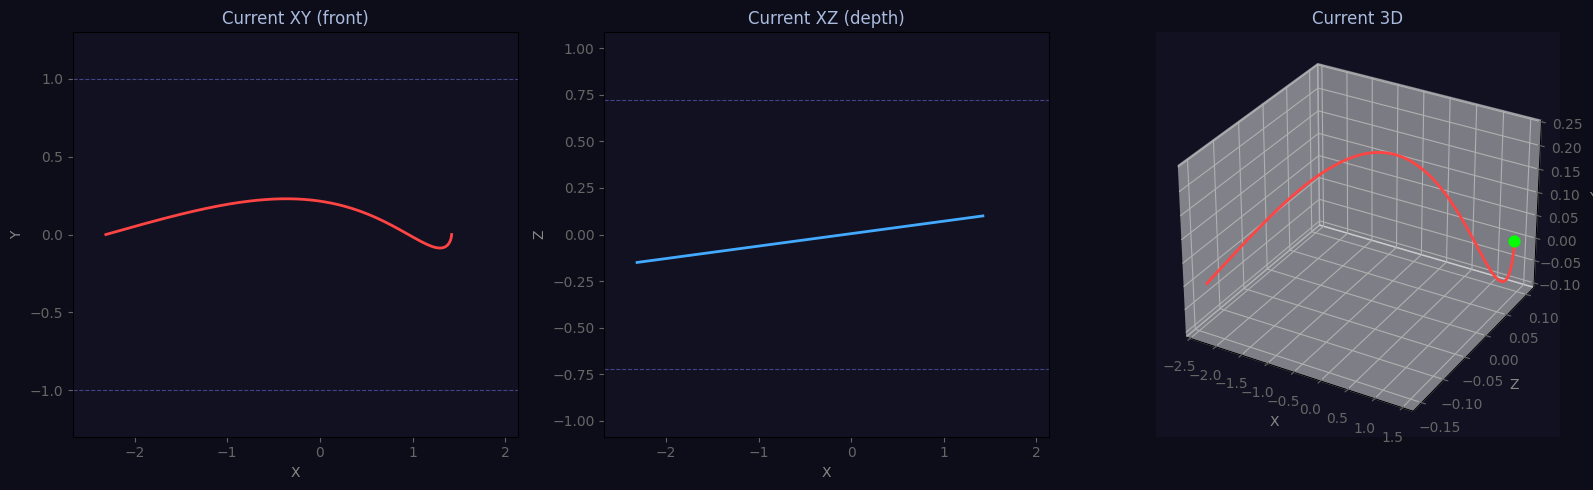

Y range: -0.087 to 0.230 (swimRangeY=1.00)
Z range: -0.150 to 0.100 (swimRangeZ=0.72)


In [2]:
# --- CURRENT entrance path (matches existing TypeScript) ---
startX = -swimRangeX * 1.3
endX = swimRangeX * 0.8

curr_x = startX + (endX - startX) * easeOut
curr_y = 0.3 * np.sin(t * np.pi * 2) * (1 - t)
curr_z = -0.15 + 0.25 * easeOut

# Plot current
fig = plt.figure(figsize=(16, 5), facecolor='#0d0d1a')

ax1 = fig.add_subplot(131, facecolor='#111122')
ax1.plot(curr_x, curr_y, '#ff4444', linewidth=2)
ax1.set_title('Current XY (front)', color='#aabbdd')
ax1.set_xlabel('X', color='#888')
ax1.set_ylabel('Y', color='#888')
ax1.axhline(swimRangeY, color='#444488', ls='--', lw=0.8)
ax1.axhline(-swimRangeY, color='#444488', ls='--', lw=0.8)
ax1.set_xlim(-swimRangeX*1.5, swimRangeX*1.2)
ax1.set_ylim(-swimRangeY*1.3, swimRangeY*1.3)
ax1.tick_params(colors='#666')

ax2 = fig.add_subplot(132, facecolor='#111122')
ax2.plot(curr_x, curr_z, '#44aaff', linewidth=2)
ax2.set_title('Current XZ (depth)', color='#aabbdd')
ax2.set_xlabel('X', color='#888')
ax2.set_ylabel('Z', color='#888')
ax2.axhline(swimRangeZ, color='#444488', ls='--', lw=0.8)
ax2.axhline(-swimRangeZ, color='#444488', ls='--', lw=0.8)
ax2.set_xlim(-swimRangeX*1.5, swimRangeX*1.2)
ax2.set_ylim(-swimRangeZ*1.5, swimRangeZ*1.5)
ax2.tick_params(colors='#666')

ax3 = fig.add_subplot(133, projection='3d', facecolor='#111122')
ax3.plot(curr_x, curr_z, curr_y, '#ff4444', linewidth=2)
ax3.scatter([curr_x[-1]], [curr_z[-1]], [curr_y[-1]], color='#00ff00', s=60)
ax3.set_title('Current 3D', color='#aabbdd')
ax3.set_xlabel('X', color='#888')
ax3.set_ylabel('Z', color='#888')
ax3.set_zlabel('Y', color='#888')
ax3.tick_params(colors='#666')

plt.tight_layout()
plt.show()
print(f"Y range: {curr_y.min():.3f} to {curr_y.max():.3f} (swimRangeY={swimRangeY:.2f})")
print(f"Z range: {curr_z.min():.3f} to {curr_z.max():.3f} (swimRangeZ={swimRangeZ:.2f})")

## Proposed Entrance (tunable parameters)

Change these values and re-run to experiment:
- `Y_AMPLITUDE`: how high the vertical undulation goes (fraction of swimRangeY)
- `Y_CYCLES`: number of sine wave cycles during entrance
- `Z_AMPLITUDE`: depth variation (fraction of swimRangeZ)
- `Z_CYCLES`: depth oscillation cycles (1.5 = dive forward then retreat)

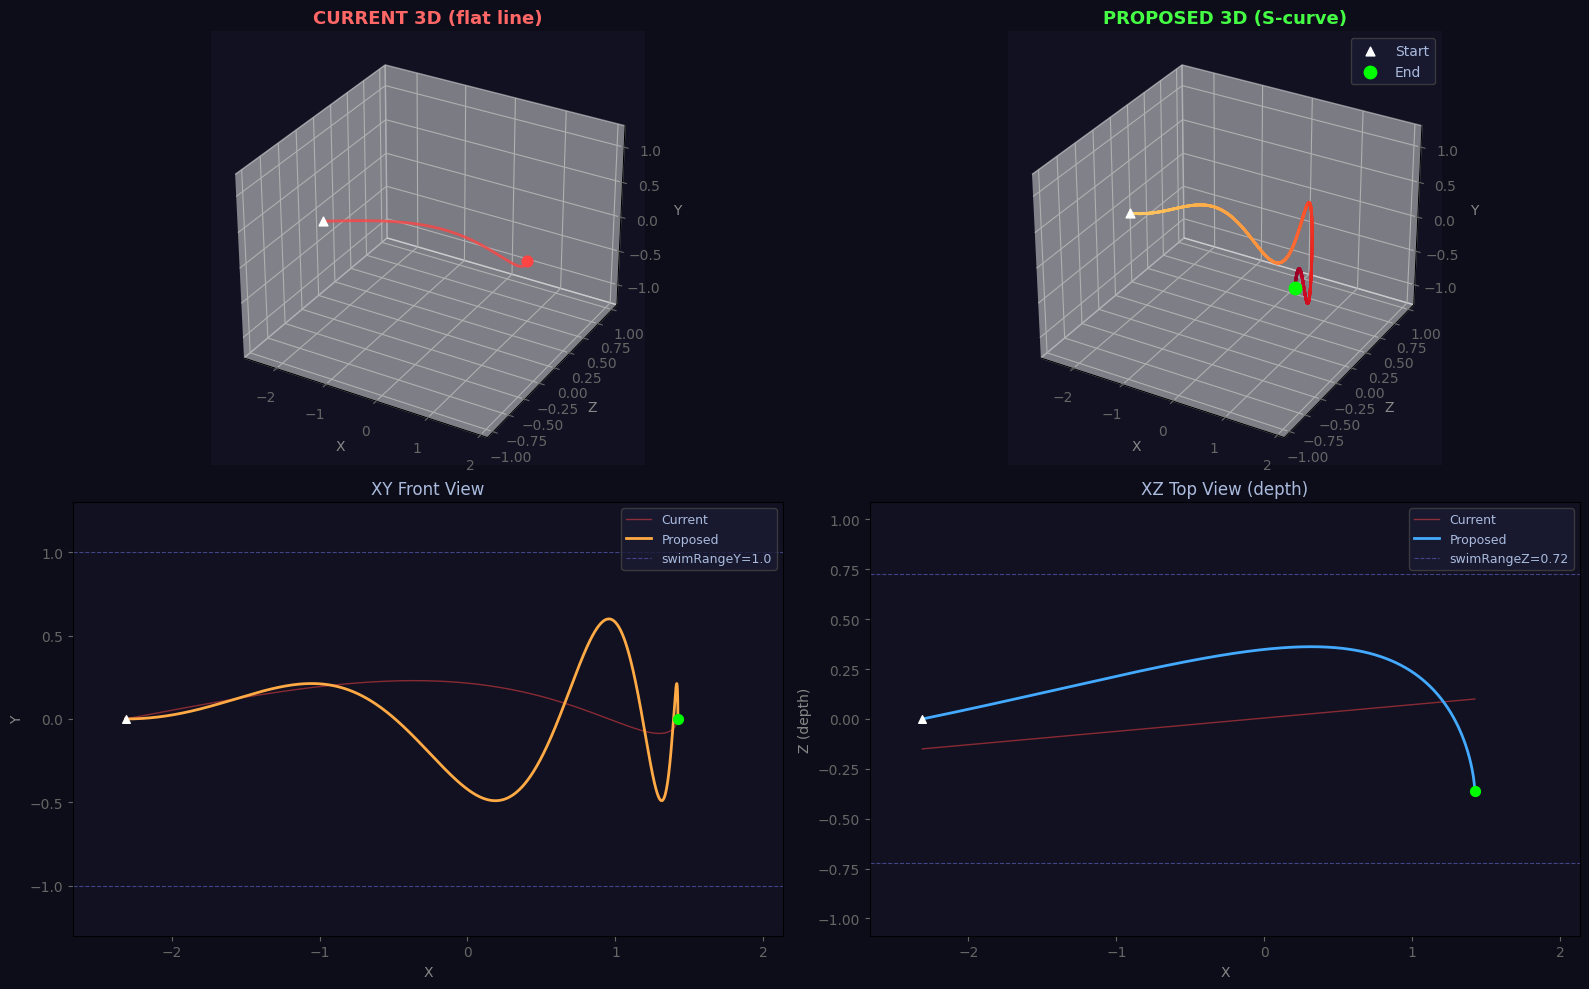


Proposed Y range: -0.490 to 0.600 (uses 60% of swimRangeY)
Proposed Z range: -0.362 to 0.362 (uses 50% of swimRangeZ)


In [3]:
# ===== TWEAK THESE =====
Y_AMPLITUDE = 0.6        # fraction of swimRangeY (0.6 = 60% of screen height)
Y_CYCLES = 2.5           # number of vertical wave cycles
Z_AMPLITUDE = 0.5        # fraction of swimRangeZ
Z_CYCLES = 1.5           # depth wave cycles (1.5 = forward-back-forward)
# ========================

# Proposed path
prop_x = startX + (endX - startX) * easeOut

# Y: multi-cycle sine with bell-curve envelope (peaks mid-entrance, zero at start/end)
envelope = np.sin(np.pi * t)
prop_y = (Y_AMPLITUDE * swimRangeY) * np.sin(t * Y_CYCLES * 2 * np.pi) * envelope

# Z: sinusoidal depth — whale approaches camera and retreats
prop_z = (Z_AMPLITUDE * swimRangeZ) * np.sin(t * Z_CYCLES * np.pi)

# --- Side-by-side comparison ---
fig = plt.figure(figsize=(16, 10), facecolor='#0d0d1a')

# Current 3D
ax1 = fig.add_subplot(221, projection='3d', facecolor='#111122')
ax1.plot(curr_x, curr_z, curr_y, '#ff4444', linewidth=2, alpha=0.8)
ax1.scatter([curr_x[0]], [curr_z[0]], [curr_y[0]], color='white', s=40, marker='^')
ax1.scatter([curr_x[-1]], [curr_z[-1]], [curr_y[-1]], color='#ff4444', s=60)
ax1.set_title('CURRENT 3D (flat line)', color='#ff6666', fontsize=13, fontweight='bold')
ax1.set_xlabel('X', color='#888'); ax1.set_ylabel('Z', color='#888'); ax1.set_zlabel('Y', color='#888')
ax1.set_xlim(-swimRangeX*1.5, swimRangeX*1.2)
ax1.set_ylim(-swimRangeZ*1.5, swimRangeZ*1.5)
ax1.set_zlim(-swimRangeY*1.3, swimRangeY*1.3)
ax1.tick_params(colors='#666')

# Proposed 3D with color gradient
ax2 = fig.add_subplot(222, projection='3d', facecolor='#111122')
colors = plt.cm.YlOrRd(np.linspace(0.3, 1.0, len(t)))
for i in range(len(t)-1):
    ax2.plot(prop_x[i:i+2], prop_z[i:i+2], prop_y[i:i+2], color=colors[i], linewidth=2)
ax2.scatter([prop_x[0]], [prop_z[0]], [prop_y[0]], color='white', s=40, marker='^', label='Start')
ax2.scatter([prop_x[-1]], [prop_z[-1]], [prop_y[-1]], color='#00ff00', s=80, label='End')
ax2.set_title('PROPOSED 3D (S-curve)', color='#44ff44', fontsize=13, fontweight='bold')
ax2.set_xlabel('X', color='#888'); ax2.set_ylabel('Z', color='#888'); ax2.set_zlabel('Y', color='#888')
ax2.set_xlim(-swimRangeX*1.5, swimRangeX*1.2)
ax2.set_ylim(-swimRangeZ*1.5, swimRangeZ*1.5)
ax2.set_zlim(-swimRangeY*1.3, swimRangeY*1.3)
ax2.tick_params(colors='#666')
ax2.legend(facecolor='#1a1a33', edgecolor='#444', labelcolor='#aabbdd')

# Proposed XY
ax3 = fig.add_subplot(223, facecolor='#111122')
ax3.plot(curr_x, curr_y, '#ff4444', linewidth=1, alpha=0.5, label='Current')
ax3.plot(prop_x, prop_y, '#ffaa44', linewidth=2, label='Proposed')
ax3.scatter([prop_x[0]], [prop_y[0]], color='white', s=30, marker='^', zorder=5)
ax3.scatter([prop_x[-1]], [prop_y[-1]], color='#00ff00', s=50, zorder=5)
ax3.axhline(swimRangeY, color='#444488', ls='--', lw=0.8, label=f'swimRangeY={swimRangeY:.1f}')
ax3.axhline(-swimRangeY, color='#444488', ls='--', lw=0.8)
ax3.set_title('XY Front View', color='#aabbdd', fontsize=12)
ax3.set_xlabel('X', color='#888'); ax3.set_ylabel('Y', color='#888')
ax3.set_xlim(-swimRangeX*1.5, swimRangeX*1.2)
ax3.set_ylim(-swimRangeY*1.3, swimRangeY*1.3)
ax3.tick_params(colors='#666')
ax3.legend(facecolor='#1a1a33', edgecolor='#444', labelcolor='#aabbdd', fontsize=9)

# Proposed XZ
ax4 = fig.add_subplot(224, facecolor='#111122')
ax4.plot(curr_x, curr_z, '#ff4444', linewidth=1, alpha=0.5, label='Current')
ax4.plot(prop_x, prop_z, '#44aaff', linewidth=2, label='Proposed')
ax4.scatter([prop_x[0]], [prop_z[0]], color='white', s=30, marker='^', zorder=5)
ax4.scatter([prop_x[-1]], [prop_z[-1]], color='#00ff00', s=50, zorder=5)
ax4.axhline(swimRangeZ, color='#444488', ls='--', lw=0.8, label=f'swimRangeZ={swimRangeZ:.2f}')
ax4.axhline(-swimRangeZ, color='#444488', ls='--', lw=0.8)
ax4.set_title('XZ Top View (depth)', color='#aabbdd', fontsize=12)
ax4.set_xlabel('X', color='#888'); ax4.set_ylabel('Z (depth)', color='#888')
ax4.set_xlim(-swimRangeX*1.5, swimRangeX*1.2)
ax4.set_ylim(-swimRangeZ*1.5, swimRangeZ*1.5)
ax4.tick_params(colors='#666')
ax4.legend(facecolor='#1a1a33', edgecolor='#444', labelcolor='#aabbdd', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nProposed Y range: {prop_y.min():.3f} to {prop_y.max():.3f} (uses {abs(prop_y).max()/swimRangeY*100:.0f}% of swimRangeY)")
print(f"Proposed Z range: {prop_z.min():.3f} to {prop_z.max():.3f} (uses {abs(prop_z).max()/swimRangeZ*100:.0f}% of swimRangeZ)")

## Velocity & Animation Direction Preview

Shows the instantaneous velocity components. The whale's animation direction is picked from the dominant velocity axis — this preview shows which direction would be active at each point in the entrance.

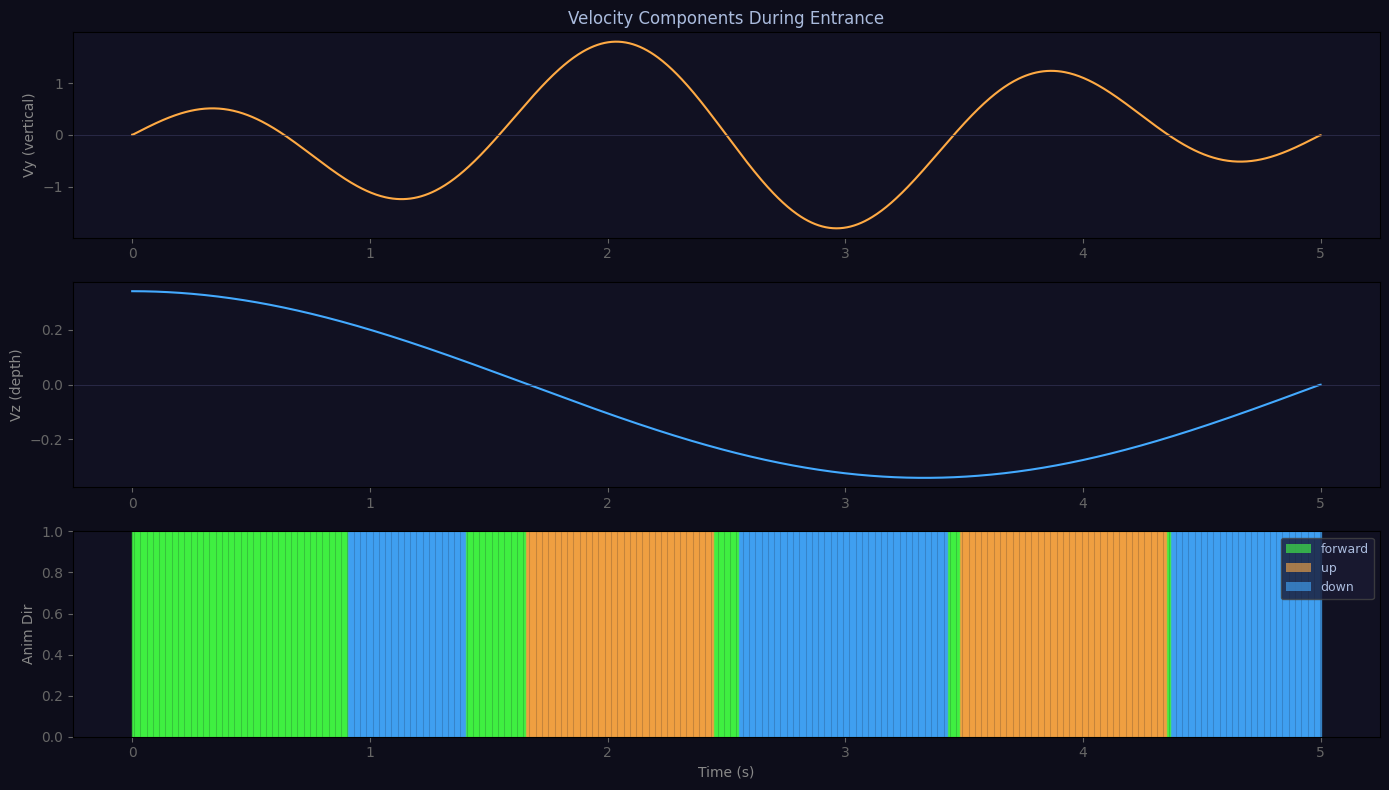

Direction changes: 9 over 5.0s


In [4]:
# Compute velocities (numerical derivative)
dt = 1.0 / len(t)
vx = np.gradient(prop_x, dt) / ENTRANCE_DURATION
vy = np.gradient(prop_y, dt) / ENTRANCE_DURATION
vz = np.gradient(prop_z, dt) / ENTRANCE_DURATION

# Determine animation direction at each point
def pick_direction(vx, vy):
    """Same logic as computeDesiredDirection in TypeScript"""
    angle = np.arctan2(vy, vx) * 180 / np.pi  # degrees
    dirs = []
    for a in angle:
        abs_a = abs(a)
        if abs_a < 30:
            dirs.append('forward')  # rightward
        elif abs_a > 150:
            dirs.append('forward')  # leftward (still forward anim)
        elif a > 0:
            dirs.append('up')
        else:
            dirs.append('down')
    return dirs

directions = pick_direction(vx, vy)
time_s = t * ENTRANCE_DURATION

fig, axes = plt.subplots(3, 1, figsize=(14, 8), facecolor='#0d0d1a')

# Velocity components
for ax, (v, label, color) in zip(axes[:2], [(vy, 'Vy (vertical)', '#ffaa44'), (vz, 'Vz (depth)', '#44aaff')]):
    ax.set_facecolor('#111122')
    ax.plot(time_s, v, color, linewidth=1.5)
    ax.axhline(0, color='#333355', lw=0.5)
    ax.set_ylabel(label, color='#888')
    ax.tick_params(colors='#666')

axes[0].set_title('Velocity Components During Entrance', color='#aabbdd', fontsize=12)

# Direction timeline
ax_dir = axes[2]
ax_dir.set_facecolor('#111122')
dir_colors = {'forward': '#44ff44', 'up': '#ffaa44', 'down': '#44aaff', 'left': '#ff44ff', 'right': '#ff4444'}
for i in range(len(time_s)-1):
    ax_dir.axvspan(time_s[i], time_s[i+1], color=dir_colors.get(directions[i], '#666'), alpha=0.6)
ax_dir.set_ylabel('Anim Dir', color='#888')
ax_dir.set_xlabel('Time (s)', color='#888')
ax_dir.tick_params(colors='#666')
# Legend
from matplotlib.patches import Patch
legend_items = [Patch(facecolor=c, label=d, alpha=0.6) for d, c in dir_colors.items() if d in directions]
ax_dir.legend(handles=legend_items, facecolor='#1a1a33', edgecolor='#444', labelcolor='#aabbdd', fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

# Count direction changes
changes = sum(1 for i in range(1, len(directions)) if directions[i] != directions[i-1])
print(f"Direction changes: {changes} over {ENTRANCE_DURATION}s")

## TypeScript Code to Copy

Once you're happy with the parameters, here's the exact code to replace in `hero-egg-3d.component.ts`.

In [5]:
# Generate the TypeScript snippet with your chosen parameters
print(f"""
// ---- Replace the Y and Z lines in the entrance block ----

// Y: {Y_CYCLES} undulation cycles with bell-curve envelope
const WAVE_AMPLITUDE = {Y_AMPLITUDE};
const WAVE_CYCLES = {Y_CYCLES};
const envelope = Math.sin(Math.PI * t);
this.whalePos.y = WAVE_AMPLITUDE * this.swimRangeY * Math.sin(t * WAVE_CYCLES * 2 * Math.PI) * envelope;

// Z: sinusoidal depth — whale approaches camera then retreats
const Z_AMP = {Z_AMPLITUDE};
const Z_CYCLES = {Z_CYCLES};
this.whalePos.z = Z_AMP * this.swimRangeZ * Math.sin(t * Z_CYCLES * Math.PI);
""")


// ---- Replace the Y and Z lines in the entrance block ----

// Y: 2.5 undulation cycles with bell-curve envelope
const WAVE_AMPLITUDE = 0.6;
const WAVE_CYCLES = 2.5;
const envelope = Math.sin(Math.PI * t);
this.whalePos.y = WAVE_AMPLITUDE * this.swimRangeY * Math.sin(t * WAVE_CYCLES * 2 * Math.PI) * envelope;

// Z: sinusoidal depth — whale approaches camera then retreats
const Z_AMP = 0.5;
const Z_CYCLES = 1.5;
this.whalePos.z = Z_AMP * this.swimRangeZ * Math.sin(t * Z_CYCLES * Math.PI);

